#First

In [ ]:
import pandas as pd
import torch
import os

#print(os.getcwd()) 
#print(os.listdir())

# This automatically detects if a GPU (CUDA) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the train and test files
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# Look at the first 5 rows of your training data
print(train.head())

# Check how much data you have
print(f"\nTraining set size: {len(train)} rows")


Using device: cuda
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

Training set size: 120000 rows


Class Distribution:
Class Index
World       30000
Sports      30000
Business    30000
Sci/Tech    30000
Name: count, dtype: int64


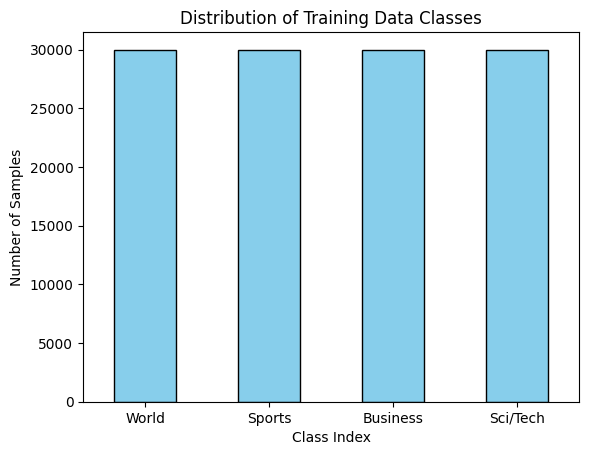

In [ ]:
import matplotlib.pyplot as plt

# This dictionary is the "translation table": number → name
CLASS_NAMES = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

# Count occurrences of each class index
class_counts = train["Class Index"].value_counts().sort_index()

#  swap out the numeric index for the names
class_counts.index = class_counts.index.map(CLASS_NAMES)
print("Class Distribution:")
print(class_counts)

# Visualize the distribution
class_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution of Training Data Classes")
plt.xlabel("Class Index")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()


Runtime Tracker

In [ ]:
import time

class RuntimeTracker:

    def __init__(self):
        self.records = {}   # stores {name: seconds}
        self._current_name = None
        self._start_time   = None

    def __call__(self, name):       
        self._current_name = name
        return self

    def __enter__(self):
        self._start_time = time.time()
        print(f"  Timing: {self._current_name} started...")
        return self

    def __exit__(self, *args):
        elapsed = time.time() - self._start_time
        self.records[self._current_name] = elapsed
        print(f"  {self._current_name} finished in {elapsed:.1f}s ({elapsed/60:.1f} min)")

    def summary(self):
        # Print a comparison table of all recorded runtimes
        print("\n" + "=" * 40)
        print("Runtime Summary")
        print("=" * 40)
        print(f"{'Model':<25} | {'Seconds':>8} | {'Minutes':>8}")
        print("-" * 40)
        for name, secs in self.records.items():
            print(f"{name:<25} | {secs:>8.1f} | {secs/60:>8.1f}")
        print("=" * 40)

tracker = RuntimeTracker() 
print("=" * 40)


Evaluator Helper


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np


class ModelEvaluator:
    def __init__(self, y_true, y_pred, class_names=list(CLASS_NAMES.values())):
        """
        y_true and y_pred should be numpy arrays or lists.
        class_names: list of strings (e.g., ["Sports", "World", ...])
        """
        self.y_true = y_true
        self.y_pred = y_pred
        self.class_names = (
            class_names
            if class_names
            else [f"{i + 1}" for i in range(len(np.unique(y_true)))]
        )

    def show_report(self):
        print("\n--- Classification Report ---")
        print(
            classification_report(
                self.y_true, self.y_pred, target_names=self.class_names
            )
        )

    def plot_confusion_matrix(self):
        cm = confusion_matrix(self.y_true, self.y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=self.class_names,
            yticklabels=self.class_names,
        )
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

    def plot_f1_scores(self):
        f1_scores = f1_score(self.y_true, self.y_pred, average=None) * 100

        min_score = min(f1_scores)
        max_score = max(f1_scores)

        padding = 5
        bottom = max(0, min_score - padding)
        top = min(100, max_score + padding)

        plt.figure(figsize=(10, 5))
        plt.bar(self.class_names, f1_scores, color="skyblue")
        plt.ylabel("F1-Score (%)")
        plt.title("F1-Score per Class")
        plt.ylim(bottom, top)
        plt.show()

    def save_errors(self, texts, filename="model_errors.csv"):
        """
        Filters wrong predictions and saves them to a CSV with readable labels.
        texts: list or array of the original input strings
        """
        # Create a dataframe for easy handling
        df = pd.DataFrame(
            {"text": texts, "actual_idx": self.y_true, "predicted_idx": self.y_pred}
        )

        # Filter for errors
        errors = df[df["actual_idx"] != df["predicted_idx"]].copy()

        # Map indices to names if possible
        if self.class_names:
            errors["actual_label"] = [self.class_names[i-1] for i in errors["actual_idx"]]
            errors["predicted_label"] = [self.class_names[i-1] for i in errors["predicted_idx"]]

        final_errors = pd.DataFrame(
            {
                "text": errors["text"],
                "Actual Class": errors["actual_label"],
                "Predicted Class": errors["predicted_label"],
            }
        )
        final_errors.to_csv(filename, index=False)
        print(f"Success: {len(errors)} errors saved to '{filename}'")
        return final_errors

In [ ]:
# Combine Title and Description into a single 'text' column
train["text"] = train["Title"] + " " + train["Description"]
test["text"] = test["Title"] + " " + test["Description"]

# Keep only the columns we need (the Class index and the combined text)
train ["Label Name"]= train["Class Index"].map(CLASS_NAMES)

test = test[["Class Index", "text"]]

# shuffle the data so there isn't any bias 
train = train.sample(frac=1, random_state=42).reset_index(drop=True)
test = test.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the first few rows
print(train[["Label Name", "text"]].head())

  Label Name                                               text
0   Business  BBC set for major shake-up, claims newspaper L...
1   Business  Marsh averts cash crunch Embattled insurance b...
2     Sports  Jeter, Yankees Look to Take Control (AP) AP - ...
3   Sci/Tech  Flying the Sun to Safety When the Genesis caps...
4   Business  Stocks Seen Flat as Nortel and Oil Weigh  NEW ...


In [ ]:

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC



# 2. Define your Pipeline
pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), stop_words="english",max_features=30000)), 
        ("clf", LinearSVC()),
    ]
#: Enhancement 1: log-scale term fre
# ::  Enhancement 2 :# ignore terms in fewer than 2 documents (noise)
)


# 3. Use cross_val_score on the 80% (X_train_val)
# This automates the internal training/testing folds for you.
cv_scores = cross_val_score(
    pipeline, train["text"], train["Class Index"], cv=5, scoring="f1_macro"
)
print(f"Mean CV Score: {cv_scores.mean():.4f}")

# 4. Final Evaluation (Only after tuning is done)
pipeline.fit(train['text'], train['Class Index'])
final_score = pipeline.score(test['text'], test['Class Index'])
print(f"Final Hold-out Score: {final_score:.4f}")

Mean CV Score: 0.9193
Final Hold-out Score: 0.9211



--- Classification Report ---
              precision    recall  f1-score   support

       World       0.94      0.91      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.90      0.89      0.89      1900
    Sci/Tech       0.90      0.91      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



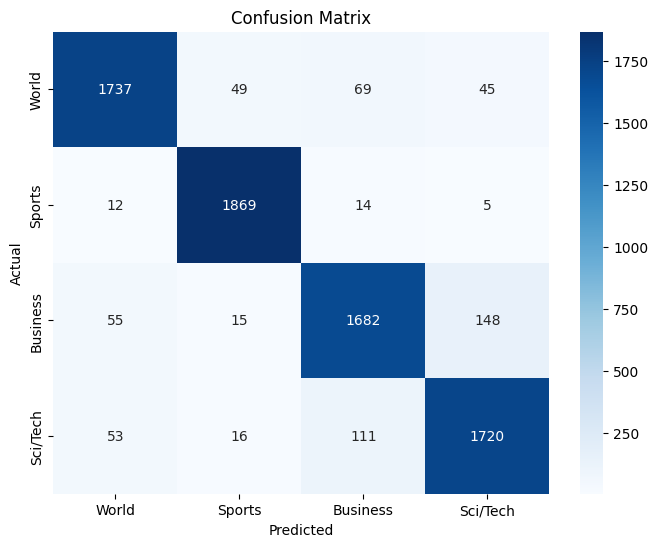

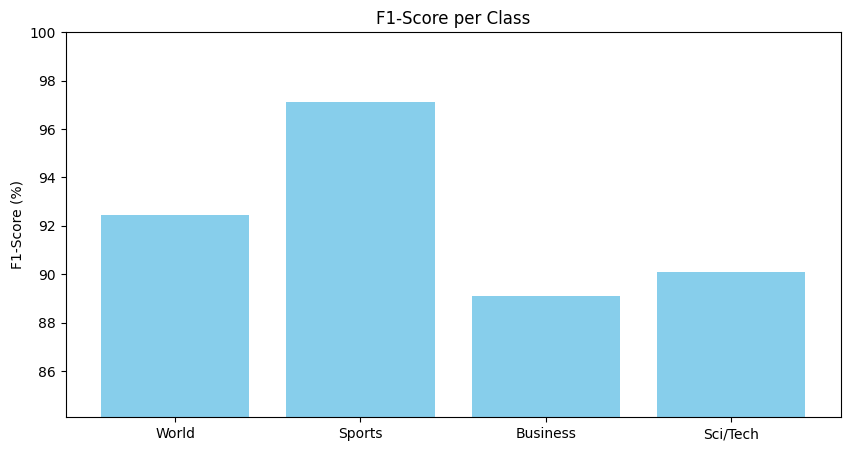

Success: 592 errors saved to 'TF-IDF_errors.csv'


,text,Actual Class,Predicted Class
1,Paris Tourists Search for Key to 'Da Vinci Cod...,World,Sci/Tech
9,Chavez rejects CD as opposition Venezuela #39;...,Business,World
18,Clouds darken PeopleSoft conference SAN FRANCI...,Business,Sci/Tech
44,Some People Not Eligible to Get in on Google I...,Sci/Tech,Business
74,Google #39;s New PC Search Tool Poses Risks NE...,Business,Sci/Tech
...,...,...,...
7532,"Gold Indian Coin Expected to Fetch #36;27,000...",Sci/Tech,World
7539,Belarus Bank Denies Money Laundering Charge A ...,Business,World
7561,"In China's changing society, psychotherapy gai...",World,Sci/Tech
7568,Feds Mum on Pre-Election Terror Threat (AP) AP...,World,Sci/Tech


In [ ]:
# 1. Generate predictions
tfidf_preds = pipeline.predict(test["text"])
tfidf_labels = test["Class Index"]  

# 2. Initialize the evaluator
evaluator = ModelEvaluator(
    y_true=tfidf_labels,
    y_pred=tfidf_preds,
    class_names=list(CLASS_NAMES.values()),
)

# 3. Call the methods
evaluator.show_report()
evaluator.plot_confusion_matrix()
evaluator.plot_f1_scores()
evaluator.save_errors(texts=test["text"],filename="TF-IDF_errors.csv")

In [ ]:
from transformers import DistilBertModel

# Load DistilBERT just to steal its embedding table

print("Extracting BERT embedding weights...")
bert_for_embeddings = DistilBertModel.from_pretrained("distilbert-base-uncased")

# .numpy() converts it to a numpy array so we can pass it around easily
bert_embedding_matrix = (
    bert_for_embeddings
    .embeddings
    .word_embeddings
    .weight
    .detach()
    .numpy()
)

print(f"Embedding matrix shape: {bert_embedding_matrix.shape}")
# Should print: (30522, 768)

# Free the memory — we only needed the weights, not the full BERT model
del bert_for_embeddings
print("Done. BERT model released from memory.")

Extracting BERT embedding weights...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding matrix shape: (30522, 768)
Done. BERT model released from memory.


In [ ]:
import torch
import torch.nn as nn


class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim,dropout=0.5 , num_layers=2,pretrained_embeddings=None):
        super(LSTM, self).__init__()

        # 1. Embedding Layer: Converts integer IDs to vectors
        # padding_idx=0 tells the model to ignore padding tokens
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            # Load the BERT embedding matrix into our table

            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_embeddings, dtype=torch.float32)
            )

            # Allowing small updates lets them adapt to news classification
            self.embedding.weight.requires_grad = True
        
        # 2. LSTM Layer: Processes the sequence
        # dropout layer to not rely on certain neurons during training
        self.dropout_layer = nn.Dropout(dropout)
        # batch_first=True means input shape is (batch, seq_len, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0 )

        # 3. Linear Layer: Maps final hidden state to the 4 classes 
        # The *2 is for the bidirectional
        self.fc = nn.Linear(hidden_dim*2, output_dim)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.embedding(x)
        # output: [batch_size, seq_len, hidden_dim]
        # (hidden, cell): state of the LSTM at the end of the sequence
        output, (hidden, cell) = self.lstm(embedded)

        # We take the final hidden state [-1] for classification
        # hidden shape: [1, batch_size, hidden_dim]
        # last_hidden = self.dropout_layer(hidden[-1])

        # Concatenate the forward [-2] and backward [-1] hidden states
        # Result shape: [batch_size, hidden_dim * 2]
        last_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        last_hidden = self.dropout_layer(last_hidden)

        return self.fc(last_hidden)


In [ ]:
import torch.optim as optim


# --- DEFINE TRAINING FUNCTION ---
def train_model(model, loader, criterion, optimizer,device):
    model.train()  
    total_loss = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()  # Clear gradients
        predictions = model(x_batch)  # Forward pass
        loss = criterion(predictions, y_batch)  # Calculate loss
        loss.backward()  # Backward pass
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping
        optimizer.step()  # Update weights

        total_loss += loss.item()

    return total_loss / len(loader)


# --- DEFINE EVALUATION FUNCTION ---
def evaluate_model(model, loader, criterion,device):
    model.eval()  
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # No gradients needed for testing
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)

            total_loss += loss.item()

            
            _, predicted = torch.max(predictions, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    return total_loss / len(loader), correct / total


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader , random_split

# 1. HuggingFace Tokenizer (The "Processor")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(len(tokenizer.vocab))

# 2. PyTorch Dataset & LSTM Model
class TextDataset(Dataset):
    def __init__(self, df, max_len=64):
        self.texts = df["text"].values
        self.labels = df["Class Index"].values - 1  # Assuming 1-based indexing
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Convert text to numerical IDs
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        return encoding["input_ids"].squeeze(), torch.tensor(self.labels[idx])
        #Removes extra dimensions : like turning a 1x64 list into a simple 64 list

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

30522


In [ ]:
# Create datasets
train_dataset = TextDataset(train, max_len=128)
test_dataset = TextDataset(test, max_len=128)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size #validation

# 3. Split the data
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
# Create loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


LSTM Model  Instantiation

In [ ]:
# 1. Instantiate your model
EMBED_DIM = 768   # must match BERT's dimension
model = LSTM(vocab_size=30522, embed_dim=EMBED_DIM, hidden_dim=512, output_dim=4,    dropout = 0.5, num_layers= 2,pretrained_embeddings = bert_embedding_matrix )
model = model.to(device)

# 2. Define the "engine" settings
criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)
optimizer = optim.Adam([
    {"params": model.embedding.parameters(), "lr": 1e-4},   # BERT embeddings: gentle updates
    {"params": model.lstm.parameters(),      "lr": 1e-3},   # LSTM weights: normal
    {"params": model.fc.parameters(),        "lr": 1e-3},   # Linear layer: normal
], weight_decay=1e-4)
# Initialize scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.1, patience=2,
)


In [ ]:
import time 
best_val_loss = float("inf")
passes = 10

# --- Storage for plotting ---
history = {
    "train_loss": [],
    "val_loss":   [],
    "val_acc":    [],
}

print(
    f"{'Epoch':<8} | {'Train Loss':<12} | {'Val Loss':<12} | {'Val Acc':<10} | {'Status':<10}"
)

print("-" * 65)
with tracker("LSTM (10 epochs)"):
    for p in range(passes):
    # 1. Training Phase
        train_loss = train_model(model, train_loader, criterion, optimizer, device)

    # 2. Validation Phase
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

        scheduler.step(val_loss)
    
    # 3. Store metrics
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc * 100)
    

    # 4. Saving the Best Model
        status = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")
            status = "SAVED"

        print(
            f"{p + 1:<8} | {train_loss:<12.4f} | {val_loss:<12.4f} | {val_acc * 100:<9.2f}% | {status:<10}"
        )

# --- FINAL EVALUATION ---
    print("\n" + "=" * 40)
    print("Training Complete. Loading Best Model...")
    print("=" * 40)

# Load the weights from the best-performing epoch
    model.load_state_dict(torch.load("best_model.pth"))

# Run final test
    test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)

    print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

tracker.summary(); 

# ── Plot 1: Train loss vs. Validation loss ─────────────────────────────────
epochs = range(1, passes + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss",      color="steelblue")
plt.plot(epochs, history["val_loss"],   marker="o", label="Validation Loss", color="tomato")
plt.axvline(x=history["val_loss"].index(min(history["val_loss"])) + 1,
            color="gray", linestyle="--", label="Best epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM — Train Loss vs. Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: Validation accuracy over epochs ────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(epochs, history["val_acc"], marker="o", color="mediumseagreen", label="Val Accuracy")
plt.axhline(y=test_acc * 100, color="tomato", linestyle="--",
            label=f"Final Test Acc: {test_acc*100:.2f}%")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("LSTM — Validation Accuracy per Epoch")
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
import torch


def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            outputs = model(x_batch)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    return all_labels, all_preds


In [ ]:
# 1. Get predictions from your helper function
lstm_labels, lstm_preds = get_predictions(model, test_loader, device)

# 2. Initialize the evaluator
# We use lstm_preds.cpu().numpy() to make sure it's a standard array
evaluator = ModelEvaluator(
    y_true=lstm_labels,
    y_pred=lstm_preds,
    class_names=["World", "Sports", "Business", "Sci/Tech"],
)

# 3. Call the methods
evaluator.show_report()
evaluator.plot_confusion_matrix()
evaluator.plot_f1_scores()
evaluator.save_errors(texts=test["text"],filename="LSTM_erros.csv")